In [ ]:
# ============================================================
# ICC305 - Avaliação de Desempenho
# Mini Estudo 1 - Estatística Descritiva
# ============================================================

# ============================================================
# 1. IMPORTS
# ============================================================

import pandas as pd
import numpy as np

from scipy import stats

import matplotlib.pyplot as plt

In [ ]:
# ============================================================
# 2. CARREGAMENTO DOS DADOS
# ============================================================

arquivo_arthur = "./tp1_resultados_art/baseline_postgres.csv"
arquivo_giovana = "./tp1_resultados_gio/baseline_postgres.csv"

df_arthur = pd.read_csv(arquivo_arthur, sep=";")
df_giovana = pd.read_csv(arquivo_giovana, sep=";")


In [ ]:
# ============================================================
# 3. UNIFICAÇÃO DOS DATASETS
# ============================================================

df = pd.concat([df_arthur, df_giovana], ignore_index=True)

print("Quantidade total de amostras:")
print(len(df))

print("\nSistemas encontrados:")
print(df["sistema"].unique())

Quantidade total de amostras:
2400

Sistemas encontrados:
<StringArray>
['sistema_arthur', 'sistema_giovana']
Length: 2, dtype: str


In [ ]:
# ============================================================
# 4. LIMPEZA E TIPAGEM
# ============================================================

df["valor"] = pd.to_numeric(df["valor"], errors="coerce")
df["tempo"] = pd.to_numeric(df["tempo"], errors="coerce")
df["num_tuplas"] = pd.to_numeric(df["num_tuplas"], errors="coerce")

df["timestamp"] = pd.to_datetime(df["timestamp"])

print("\nDados após limpeza:")
print(df.info())


Dados após limpeza:
<class 'pandas.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   run         2400 non-null   int64         
 1   timestamp   2400 non-null   datetime64[us]
 2   sistema     2400 non-null   str           
 3   query_id    2400 non-null   int64         
 4   carga       2400 non-null   str           
 5   categoria   2400 non-null   str           
 6   metrica     2400 non-null   str           
 7   unidade     2400 non-null   str           
 8   valor       2400 non-null   float64       
 9   tempo       2400 non-null   float64       
 10  num_tuplas  2400 non-null   int64         
 11  observacao  2400 non-null   str           
dtypes: datetime64[us](1), float64(2), int64(3), str(6)
memory usage: 225.1 KB
None


In [ ]:
# ============================================================
# 5. FUNÇÃO AUXILIAR PARA IC95%
# ============================================================
import numpy as np
import scipy.stats as st

def intervalo_confianca_95(valores):
    n = len(valores)
    media = np.mean(valores)
    
    if n < 2:
        return media, media
        
    desvio = np.std(valores, ddof=1)
    
    if desvio == 0.0 or np.isnan(desvio):
        return media, media
        
    erro_padrao = desvio / np.sqrt(n)
    
    ic_inf, ic_sup = st.t.interval(0.95, df=n-1, loc=media, scale=erro_padrao)
    
    return ic_inf, ic_sup

In [25]:
# ============================================================
# 6. ESTATÍSTICA DESCRITIVA POR SISTEMA
# ============================================================

estatisticas_sistema = []

for sistema, grupo in df.groupby("sistema"):

    valores = grupo["valor"]

    ic_inf, ic_sup = intervalo_confianca_95(valores)

    estatisticas_sistema.append({
        "sistema": sistema,
        "n_amostras": len(valores),
        "media_tp_ms": valores.mean(),
        "mediana_tp_ms": valores.median(),
        "min_tp_ms": valores.min(),
        "max_tp_ms": valores.max(),
        "desvio_padrao": valores.std(),
        "ic95_inf": ic_inf,
        "ic95_sup": ic_sup
    })

df_estatisticas_sistema = pd.DataFrame(estatisticas_sistema)

print("\n===================================================")
print("ESTATÍSTICA DESCRITIVA POR SISTEMA")
print("===================================================\n")

print(df_estatisticas_sistema)


ESTATÍSTICA DESCRITIVA POR SISTEMA

           sistema  n_amostras  media_tp_ms  mediana_tp_ms  min_tp_ms    max_tp_ms  desvio_padrao    ic95_inf    ic95_sup
0   sistema_arthur        1200   208.042805       0.835634   0.000000  1944.135049     458.244142  182.089480  233.996131
1  sistema_giovana        1200   204.481196       0.491394   0.004344  1678.304678     415.452117  180.951459  228.010933


In [ ]:
# ============================================================
# 7. ESTATÍSTICA DESCRITIVA POR CATEGORIA
# ============================================================

estatisticas_categoria = []

for (sistema, categoria), grupo in df.groupby(["sistema", "categoria"]):
    valores = grupo["valor"]
    ic_inf, ic_sup = intervalo_confianca_95(valores)

    estatisticas_categoria.append({
        "sistema": sistema,
        "categoria": categoria,
        "n_amostras": len(valores),
        "media_tp_ms": valores.mean(),
        "mediana_tp_ms": valores.median(),
        "min_tp_ms": valores.min(),
        "max_tp_ms": valores.max(),
        "desvio_padrao": valores.std(),
        "ic95_inf": ic_inf,
        "ic95_sup": ic_sup
    })

df_estatisticas_categoria = pd.DataFrame(estatisticas_categoria)

df_estatisticas_categoria = df_estatisticas_categoria.sort_values(
    by=["categoria", "sistema"]
).reset_index(drop=True)

print("\n===================================================")
print("ESTATÍSTICA DESCRITIVA POR CATEGORIA")
print("===================================================\n")

print(df_estatisticas_categoria)


ESTATÍSTICA DESCRITIVA POR CATEGORIA

            sistema       categoria  n_amostras  media_tp_ms  mediana_tp_ms  min_tp_ms    max_tp_ms  desvio_padrao    ic95_inf    ic95_sup
0    sistema_arthur      Agregações         180     0.016718       0.006782   0.004085     0.038735       0.014225    0.014626    0.018811
1   sistema_giovana      Agregações         180     0.016644       0.007145   0.004344     0.038577       0.014434    0.014521    0.018767
2    sistema_arthur         Filtros         240   582.628172     242.819867   0.000000  1944.135049     660.346822  498.659103  666.597242
3   sistema_giovana         Filtros         240   584.483485     491.990947   0.486516  1678.304678     532.597478  516.758900  652.208070
4    sistema_arthur        Group By         150    18.309080       0.020365   0.013595   101.585639      36.696810   12.388387   24.229773
5   sistema_giovana        Group By         150    17.196906       0.022232   0.014859    91.394533      34.465466   11.636220 

In [ ]:
# ============================================================
# 8. ESTATÍSTICA DESCRITIVA POR QUERY
# ============================================================

estatisticas_query = []

for (sistema, query_id), grupo in df.groupby(["sistema", "query_id"]):

    valores = grupo["valor"]

    ic_inf, ic_sup = intervalo_confianca_95(valores)

    estatisticas_query.append({
        "sistema": sistema,
        "query_id": query_id,
        "titulo": grupo["carga"].iloc[0],
        "categoria": grupo["categoria"].iloc[0],
        "n_amostras": len(valores),
        "media_tp_ms": valores.mean(),
        "mediana_tp_ms": valores.median(),
        "min_tp_ms": valores.min(),
        "max_tp_ms": valores.max(),
        "desvio_padrao": valores.std(),
        "ic95_inf": ic_inf,
        "ic95_sup": ic_sup
    })

df_estatisticas_query = pd.DataFrame(estatisticas_query)

df_estatisticas_query = df_estatisticas_query.sort_values(
    by=["query_id", "sistema"]
).reset_index(drop=True)


print("\n===================================================")
print("ESTATÍSTICA DESCRITIVA POR QUERY")
print("===================================================\n")

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', None)

print(df_estatisticas_query)


ESTATÍSTICA DESCRITIVA POR QUERY

            sistema  query_id                                        titulo       categoria  n_amostras  media_tp_ms  mediana_tp_ms    min_tp_ms    max_tp_ms  desvio_padrao     ic95_inf     ic95_sup
0    sistema_arthur         1              Busca básica de produto por ASIN  Lookup Simples          30     0.124404       0.031331     0.029098     2.079426       0.375070    -0.015649     0.264458
1   sistema_giovana         1              Busca básica de produto por ASIN  Lookup Simples          30     0.163213       0.054991     0.050203     1.769514       0.331760     0.039332     0.287094
2    sistema_arthur         2     Busca do identificador interno do produto  Lookup Simples          30     3.856365       3.855958     0.727113     5.745706       0.910911     3.516225     4.196505
3   sistema_giovana         2     Busca do identificador interno do produto  Lookup Simples          30     5.178374       5.140245     3.462028     6.591914       0.697

<Figure size 800x600 with 0 Axes>

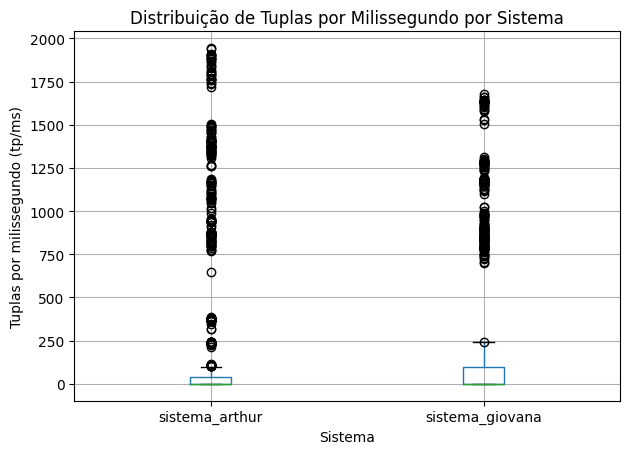

In [28]:
# ============================================================
# 9. BOXPLOT POR SISTEMA
# ============================================================

plt.figure(figsize=(8, 6))

df.boxplot(
    column="valor",
    by="sistema"
)

plt.title("Distribuição de Tuplas por Milissegundo por Sistema")
plt.suptitle("")

plt.xlabel("Sistema")
plt.ylabel("Tuplas por milissegundo (tp/ms)")

plt.tight_layout()

plt.show()

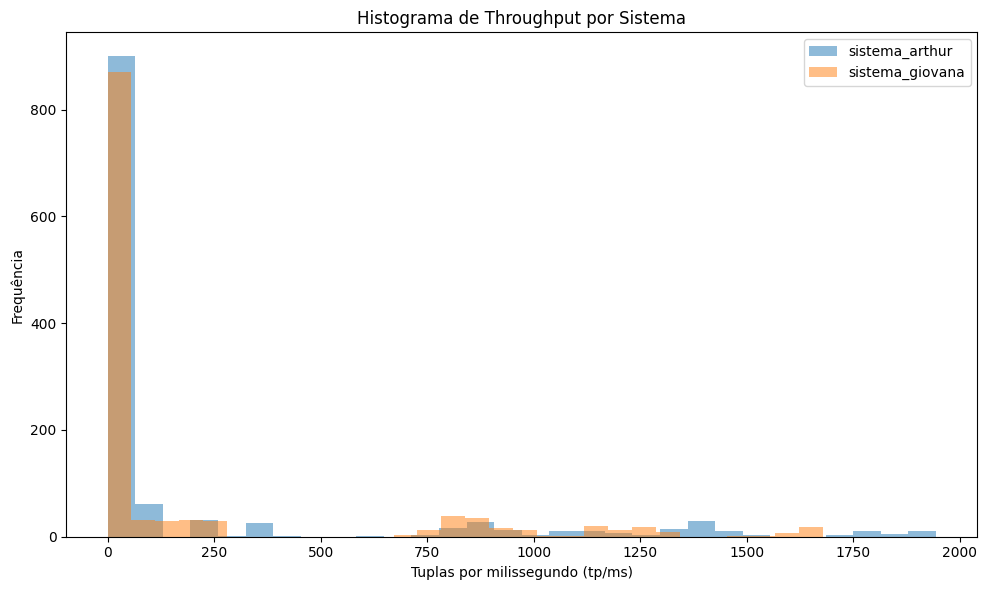

In [29]:
# ============================================================
# 10. HISTOGRAMA GERAL
# ============================================================

plt.figure(figsize=(10, 6))

for sistema in df["sistema"].unique():

    subset = df[df["sistema"] == sistema]

    plt.hist(
        subset["valor"],
        bins=30,
        alpha=0.5,
        label=sistema
    )

plt.xlabel("Tuplas por milissegundo (tp/ms)")
plt.ylabel("Frequência")

plt.title("Histograma de Throughput por Sistema")

plt.legend()

plt.tight_layout()

plt.show()

<Figure size 800x600 with 0 Axes>

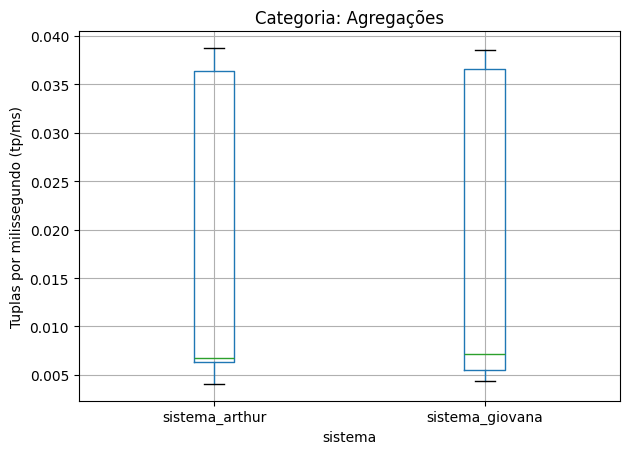

<Figure size 800x600 with 0 Axes>

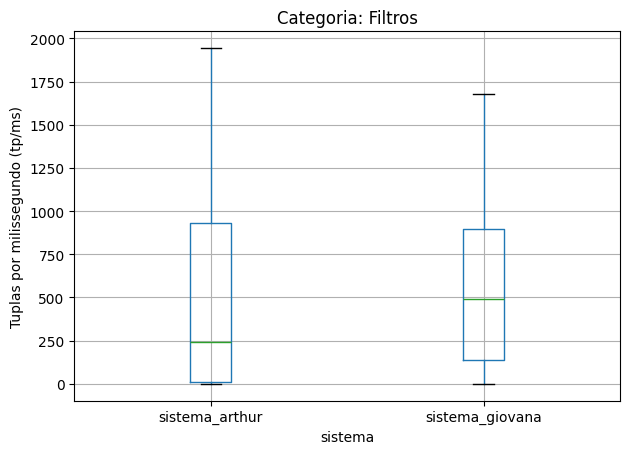

<Figure size 800x600 with 0 Axes>

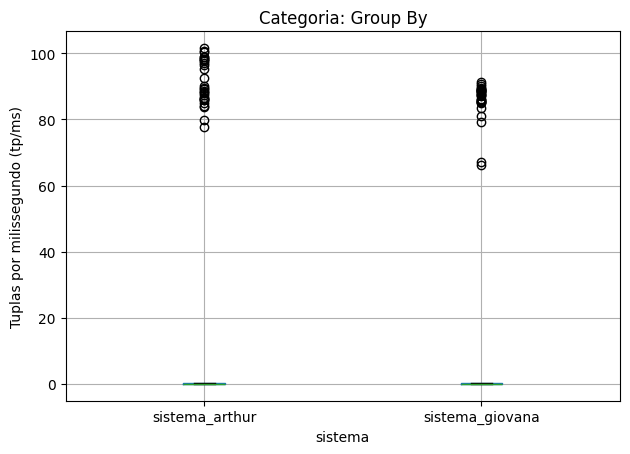

<Figure size 800x600 with 0 Axes>

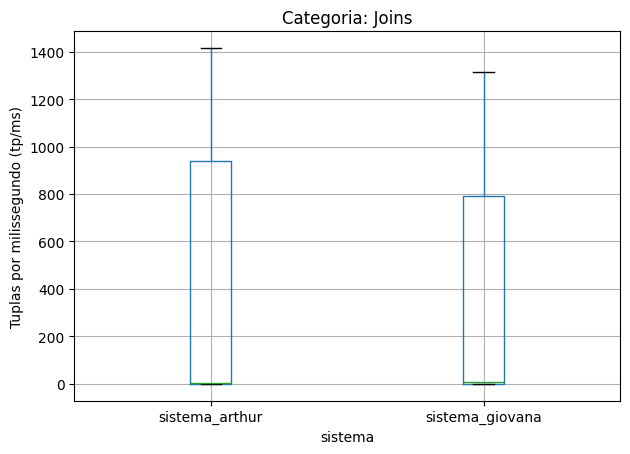

<Figure size 800x600 with 0 Axes>

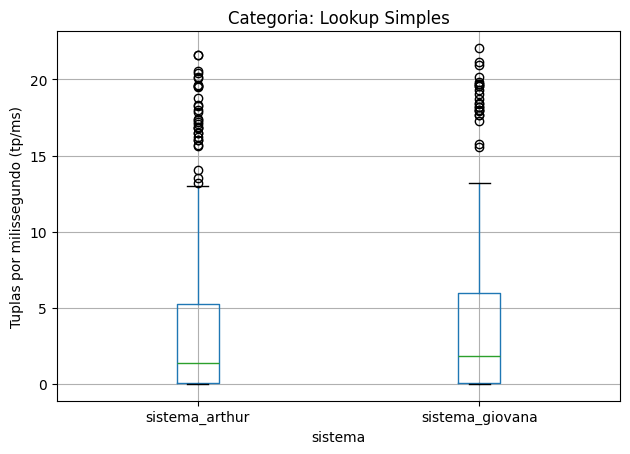

<Figure size 800x600 with 0 Axes>

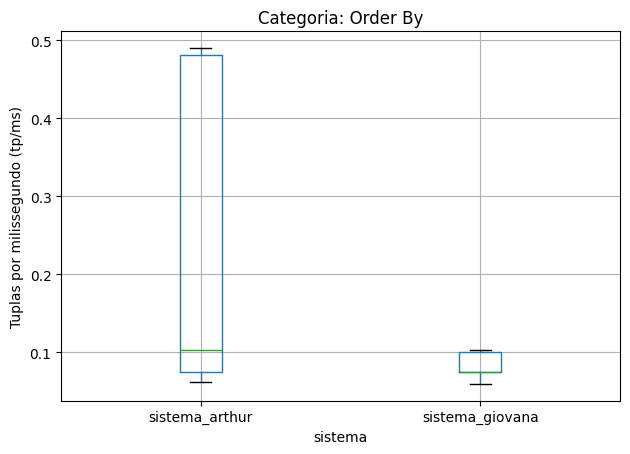

<Figure size 800x600 with 0 Axes>

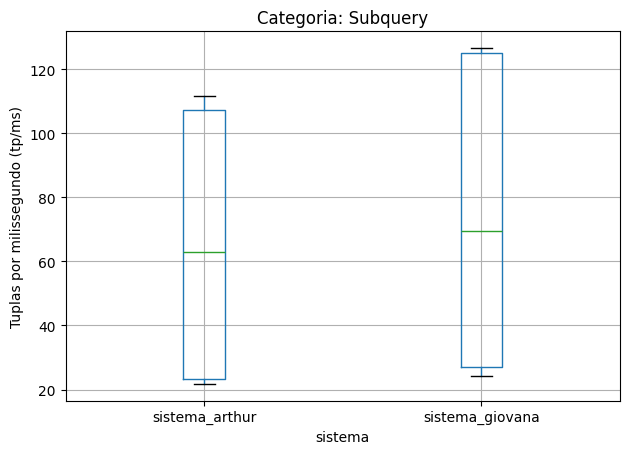

In [30]:
# ============================================================
# 11. BOXPLOT POR CATEGORIA
# ============================================================

categorias = sorted(df["categoria"].unique())

for categoria in categorias:

    subset = df[df["categoria"] == categoria]

    plt.figure(figsize=(8, 6))

    subset.boxplot(
        column="valor",
        by="sistema"
    )

    plt.title(f"Categoria: {categoria}")
    plt.suptitle("")

    plt.ylabel("Tuplas por milissegundo (tp/ms)")

    plt.tight_layout()

    plt.show()

In [32]:
# ============================================================
# 12. RESUMO FINAL
# ============================================================

print("\n===================================================")
print("RESUMO FINAL")
print("===================================================\n")

for sistema in df["sistema"].unique():

    subset = df[df["sistema"] == sistema]

    print(f"Sistema: {sistema}")
    print(f"Média tp/ms: {subset['valor'].mean():.4f}")
    print(f"Mediana tp/ms: {subset['valor'].median():.4f}")
    print(f"Desvio padrão: {subset['valor'].std():.4f}")
    print("-" * 50)


RESUMO FINAL

Sistema: sistema_arthur
Média tp/ms: 208.0428
Mediana tp/ms: 0.8356
Desvio padrão: 458.2441
--------------------------------------------------
Sistema: sistema_giovana
Média tp/ms: 204.4812
Mediana tp/ms: 0.4914
Desvio padrão: 415.4521
--------------------------------------------------
